In [1]:
# ============ CELLULE 1 — Imports ============
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ============ CELLULE 2 — Chargement ============
df = pd.read_csv("../data/Reviews.csv")
print(f"Shape: {df.shape}")
print(f"\nColonnes: {list(df.columns)}")
print(f"\nNulls:\n{df.isnull().sum()}")
print(f"\nDtypes:\n{df.dtypes}")

Shape: (568454, 10)

Colonnes: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']

Nulls:
Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

Dtypes:
Id                        int64
ProductId                   str
UserId                      str
ProfileName                 str
HelpfulnessNumerator      int64
HelpfulnessDenominator    int64
Score                     int64
Time                      int64
Summary                     str
Text                        str
dtype: object


Text(0.5, 0, 'Score')

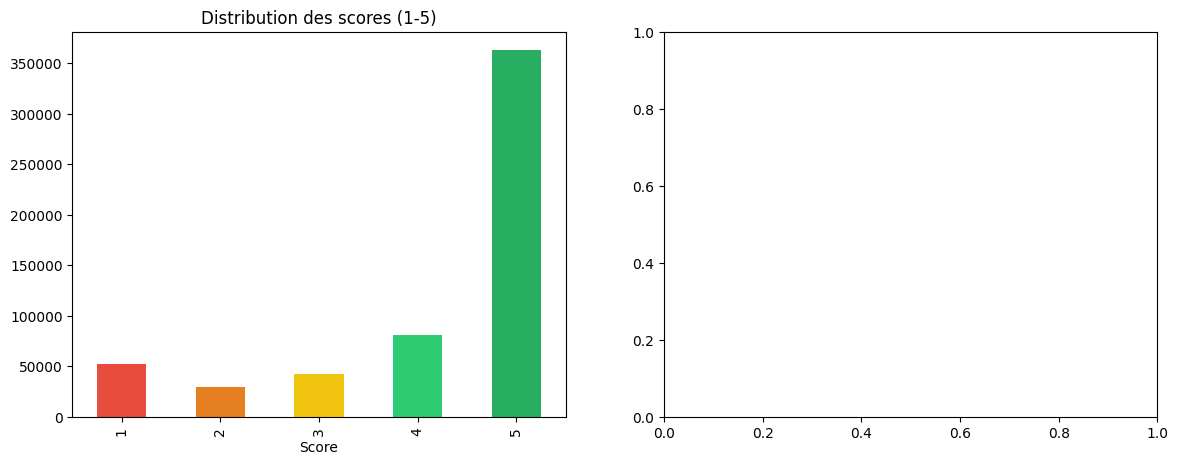

In [3]:
# ============ CELLULE 3 — Distribution des scores ============
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Score'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']
)
axes[0].set_title("Distribution des scores (1-5)")
axes[0].set_xlabel("Score")

In [4]:
# ============ CELLULE 4 — Création du label ============
def score_to_label(s):
    if s < 3:  return 0  # negative
    if s == 3: return 1  # neutral
    return 2             # positive

df['sentiment'] = df['Score'].apply(score_to_label)
label_counts = df['sentiment'].value_counts().sort_index()
label_names = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

print("Distribution classes:")
for k, v in label_counts.items():
    pct = v/len(df)*100
    print(f"  {label_names[k]}: {v:,} ({pct:.1f}%)")


Distribution classes:
  Negative: 82,037 (14.4%)
  Neutral: 42,640 (7.5%)
  Positive: 443,777 (78.1%)


In [5]:
# ============ CELLULE 5 — Stats sur les textes ============
df['text_len'] = df['Text'].fillna('').str.len()
df['summary_len'] = df['Summary'].fillna('').str.len()

print(f"\nLongueur moyenne Text: {df['text_len'].mean():.0f} chars")
print(f"Longueur moyenne Summary: {df['summary_len'].mean():.0f} chars")
print(f"\nSummary nulls: {df['Summary'].isna().sum()}")


Longueur moyenne Text: 436 chars
Longueur moyenne Summary: 23 chars

Summary nulls: 27


In [6]:
# ============ CELLULE 6 — Exemples par classe ============
for label in [0, 1, 2]:
    sample = df[df['sentiment']==label].sample(2)
    print(f"\n{'='*50}")
    print(f"CLASSE: {label_names[label]}")
    for _, row in sample.iterrows():
        print(f"  Score: {row['Score']} | Summary: {row['Summary']}")
        print(f"  Text: {str(row['Text'])[:100]}...")


CLASSE: Negative
  Score: 2 | Summary: wouldn't buy this again
  Text: Wasn't expecting much but was curious. Brewed result was very "thin" both in texture and in flavor. ...
  Score: 1 | Summary: Formula change
  Text: I had been buying these for several years.  As other reviewers stated, it usually took 3 tablets in ...

CLASSE: Neutral
  Score: 3 | Summary: coffee strength
  Text: If I had known this was a bold coffee selection I would not have purchased it. As strong coffees go ...
  Score: 3 | Summary: miss nespresso
  Text: good morning<br /><br />My order already arrived but nespresso was delivered only one package with 1...

CLASSE: Positive
  Score: 5 | Summary: Wonderful way to Sweeten Coffee
  Text: I really like the taste of the light agave nectar for coffee, cereal, just about anything.  It is no...
  Score: 4 | Summary: It keeps him occupied, but annoying to hear
  Text: My dog Cooper enjoys this toy as much as he loves his Kong toys.  He still hasn't figured out how to.